# Diabetes Risk Prediction Using Machine Learning

In [106]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [107]:
#Load dataset/

df = pd.read_csv("dataset/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [108]:
df.shape

(768, 9)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [110]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [111]:
#Data Cleaning 


from sklearn.impute import KNNImputer

cols = ['Glucose',
        'BloodPressure',
        'SkinThickness',
        'Insulin',
        'BMI']

df[cols] = df[cols].replace(0, np.nan)

imputer = KNNImputer(n_neighbors=5)

df[cols] = imputer.fit_transform(df[cols])

In [112]:
Q1 = df.quantile(0.25)

Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) |
          (df > (Q3 + 1.5 * IQR))).any(axis=1)]

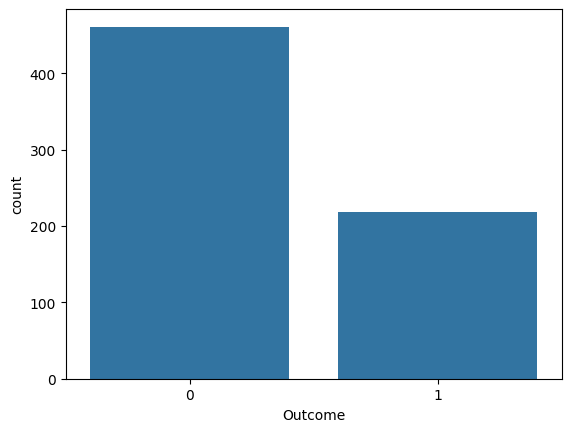

In [113]:
sns.countplot(x='Outcome', data=df)
plt.show()

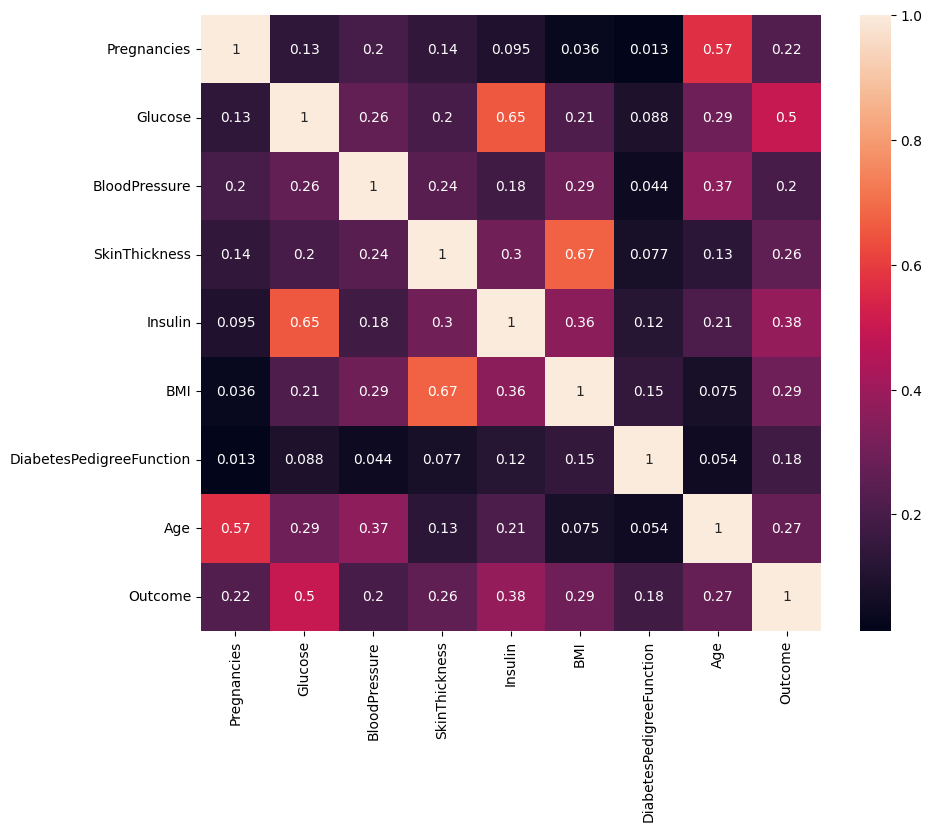

In [114]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True)

plt.show()

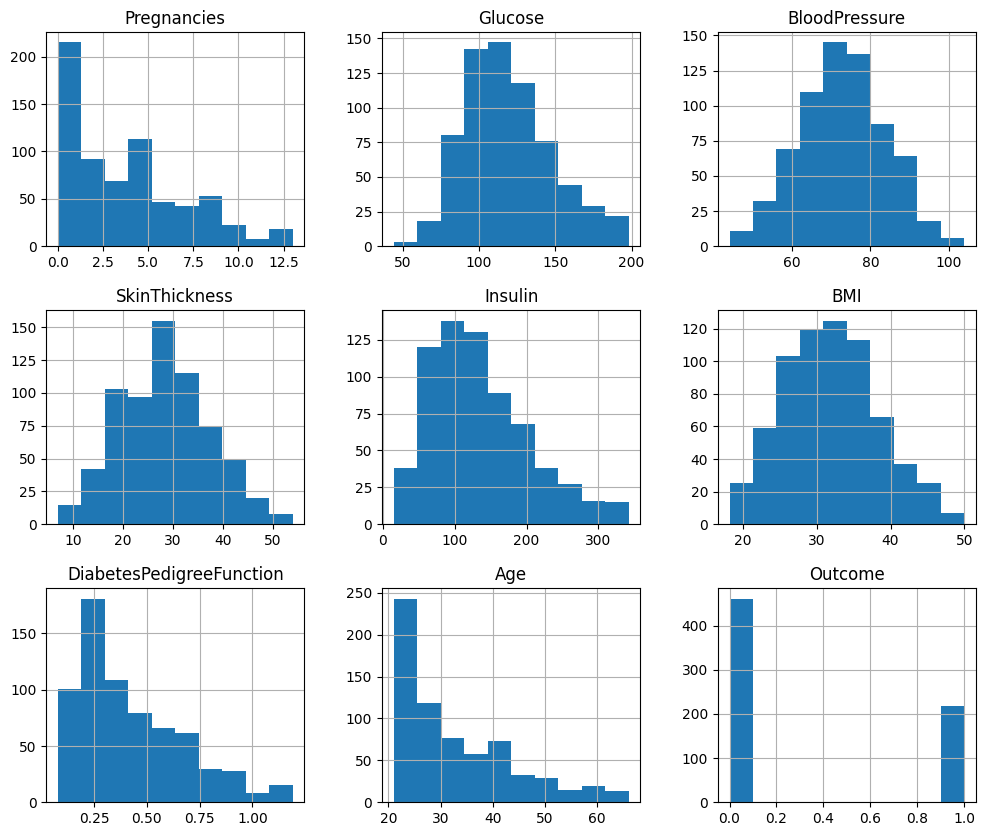

In [115]:
df.hist(figsize=(12,10))

plt.show()

In [116]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [118]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [119]:
#LOgistic Recursion


lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


print("Accuracy:",accuracy_score(y_test, y_pred_lr))

print(confusion_matrix(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7426470588235294
[[80 12]
 [23 21]]
              precision    recall  f1-score   support

           0       0.78      0.87      0.82        92
           1       0.64      0.48      0.55        44

    accuracy                           0.74       136
   macro avg       0.71      0.67      0.68       136
weighted avg       0.73      0.74      0.73       136



In [120]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


print("Accuracy:",accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7279411764705882
[[76 16]
 [21 23]]
              precision    recall  f1-score   support

           0       0.78      0.83      0.80        92
           1       0.59      0.52      0.55        44

    accuracy                           0.73       136
   macro avg       0.69      0.67      0.68       136
weighted avg       0.72      0.73      0.72       136



In [121]:
svm = SVC(
    kernel='rbf',
    C=2,
    gamma='scale'
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)


print("Accuracy:",accuracy_score(y_test, y_pred_svm))

print(confusion_matrix(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7352941176470589
[[78 14]
 [22 22]]
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        92
           1       0.61      0.50      0.55        44

    accuracy                           0.74       136
   macro avg       0.70      0.67      0.68       136
weighted avg       0.73      0.74      0.73       136



In [122]:
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Accuracy:",accuracy_score(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))

print(classification_report(y_test, y_pred_gb))

Accuracy: 0.7279411764705882
[[77 15]
 [22 22]]
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        92
           1       0.59      0.50      0.54        44

    accuracy                           0.73       136
   macro avg       0.69      0.67      0.67       136
weighted avg       0.72      0.73      0.72       136



In [123]:
%pip install xgboost

^C
Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable


In [124]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:",accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.7573529411764706


In [125]:
results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Random Forest',
        'SVM',
        'Gradient Boosting'
    ],

    'Accuracy':[
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_gb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.742647
1,Random Forest,0.727941
2,SVM,0.735294
3,Gradient Boosting,0.727941


In [126]:
%pip install tensorflow

^C
Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable


In [127]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

In [128]:
ann = Sequential()

ann.add(Dense(32,
              activation='relu',
              input_dim=8))

ann.add(Dense(16,
              activation='relu'))

ann.add(Dense(8,
              activation='relu'))

ann.add(Dense(1,
              activation='sigmoid'))


ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = ann.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2
)

y_pred_ann = ann.predict(X_test)

y_pred_ann = (y_pred_ann > 0.5)

print("ANN Accuracy:",
      accuracy_score(y_test, y_pred_ann))
print(confusion_matrix(y_test, y_pred_ann))

print(classification_report(y_test, y_pred_ann))

C:\Users\UJJWAL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.6475 - loss: 0.6382 - val_accuracy: 0.6881 - val_loss: 0.5958
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7235 - loss: 0.5573 - val_accuracy: 0.7339 - val_loss: 0.5295
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7581 - loss: 0.4932 - val_accuracy: 0.7615 - val_loss: 0.4880
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7880 - loss: 0.4506 - val_accuracy: 0.7706 - val_loss: 0.4688
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8088 - loss: 0.4221 - val_accuracy: 0.7339 - val_loss: 0.4710
Epoch 6/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8088 - loss: 0.4069 - val_accuracy: 0.7339 - val_loss: 0.4739
Epoch 7/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8018 - loss: 0.3965 - val_accuracy: 0.7248 - val_loss: 0.4734
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8065 - loss: 0.3902 - val_accuracy: 0.

In [129]:
results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Random Forest',
        'SVM',
        'Gradient Boosting',
        'Artificial Neural Network'
    ],

    'Accuracy':[
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_ann)
    ]
})

results


,Model,Accuracy
0,Logistic Regression,0.742647
1,Random Forest,0.727941
2,SVM,0.735294
3,Gradient Boosting,0.727941
4,Artificial Neural Network,0.647059


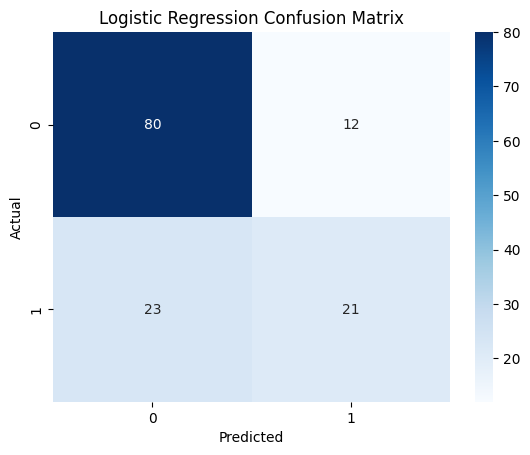

In [130]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

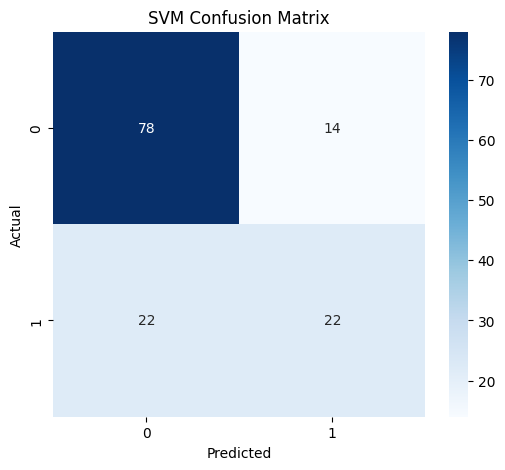

In [131]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [132]:
from sklearn.metrics import roc_auc_score

print(
    roc_auc_score(y_test, y_pred_svm)
)

0.673913043478261


In [133]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

           0       0.78      0.85      0.81        92
           1       0.61      0.50      0.55        44

    accuracy                           0.74       136
   macro avg       0.70      0.67      0.68       136
weighted avg       0.73      0.74      0.73       136



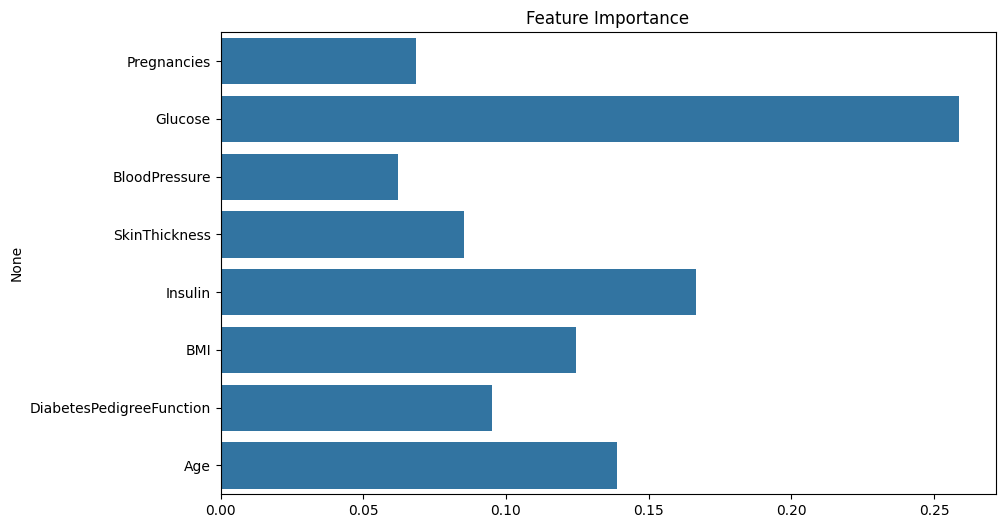

In [134]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

sns.barplot(
    x=importance,
    y=features
)

plt.title("Feature Importance")

plt.show()

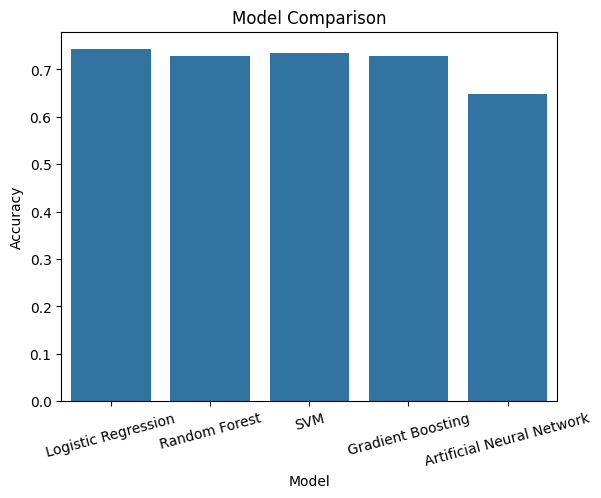

In [135]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.xticks(rotation=15)

plt.title("Model Comparison")

plt.show()

In [136]:
import pickle

pickle.dump(
    svm,
    open("models/diabetes_model.pkl", "wb")
)

In [137]:
pickle.dump(
    scaler,
    open("models/scaler.pkl", "wb")
)